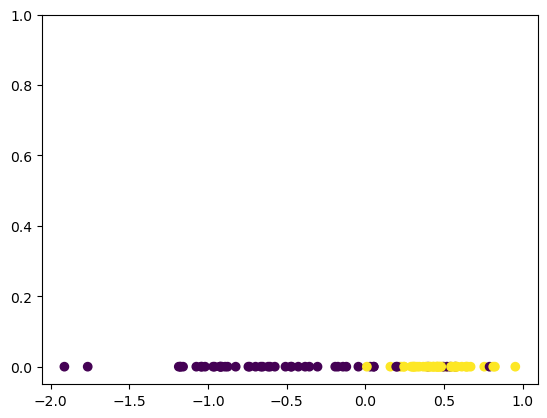

In [140]:
import sys
import numpy as np
from sklearn.datasets import make_classification

X, y = make_classification(n_classes=2, n_features=1,
               n_redundant=0, n_repeated=0, n_informative=1,
               n_clusters_per_class=1, class_sep=0.5, random_state=1)

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X, np.zeros_like(y), c=y)
plt.ylim(-0.05, 1)
plt.savefig('set.png')

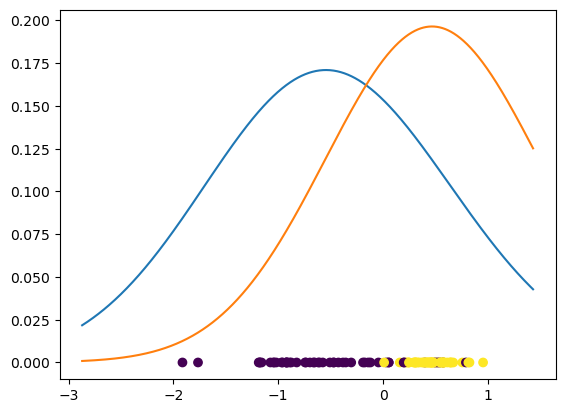

In [141]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neighbors import KernelDensity

class BayesKDE(BaseEstimator, ClassifierMixin):
  def __init__(self, bandwidth=1.0):
    self.bandwidth = bandwidth

  def fit(self, X, y):
    self.classes_ = np.unique(y)

    self.kdes_ = {}
    self.priors_ = {}

    for target in self.classes_:
      kde = KernelDensity(kernel='gaussian', bandwidth=self.bandwidth)
      kde.fit(X[y == target])
      self.kdes_[target] = kde

      self.priors_[target] = np.sum(y == target) / len(y)

    return self
  
  def score_samples(self, X):
    logprobs = np.zeros((len(X), len(self.classes_)))

    for i, target in enumerate(self.classes_):
      logprobs[:, i] = self.kdes_[target].score_samples(X) + np.log(self.priors_[target])

    return logprobs
  
  def predict(self, X):
    logprobs = self.score_samples(X)
    return np.argmax(logprobs, axis=1)

bayeskde = BayesKDE()
bayeskde.fit(X, y)
plt.figure()
plt.scatter(X, np.zeros_like(y), c=y)
x = np.linspace(np.min(X) * 1.5, np.max(X) * 1.5, 1000).reshape(-1, 1)
plt.plot(x, np.exp(bayeskde.score_samples(x)[:, 0]))
plt.plot(x, np.exp(bayeskde.score_samples(x)[:, 1]))
plt.savefig('pdfs.png')
plt.show()

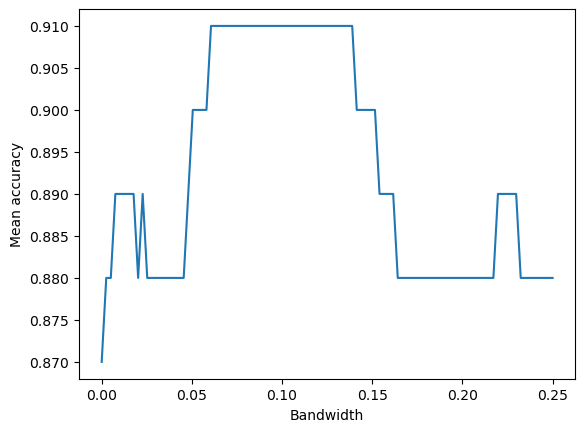

In [142]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kf = KFold(n_splits=10, shuffle=True, random_state=0)
bws = np.linspace(sys.float_info.epsilon, 0.25, 100)

mean_scores = []

for bw in bws:
  bayeskde = BayesKDE(bandwidth=bw)
  scores = cross_val_score(bayeskde, X, y, cv=kf, scoring='accuracy')
  mean_scores.append(np.mean(scores))

plt.figure()
plt.plot(bws, mean_scores)
plt.xlabel('Bandwidth')
plt.ylabel('Mean accuracy')
plt.savefig('bw_search.png')
plt.show()

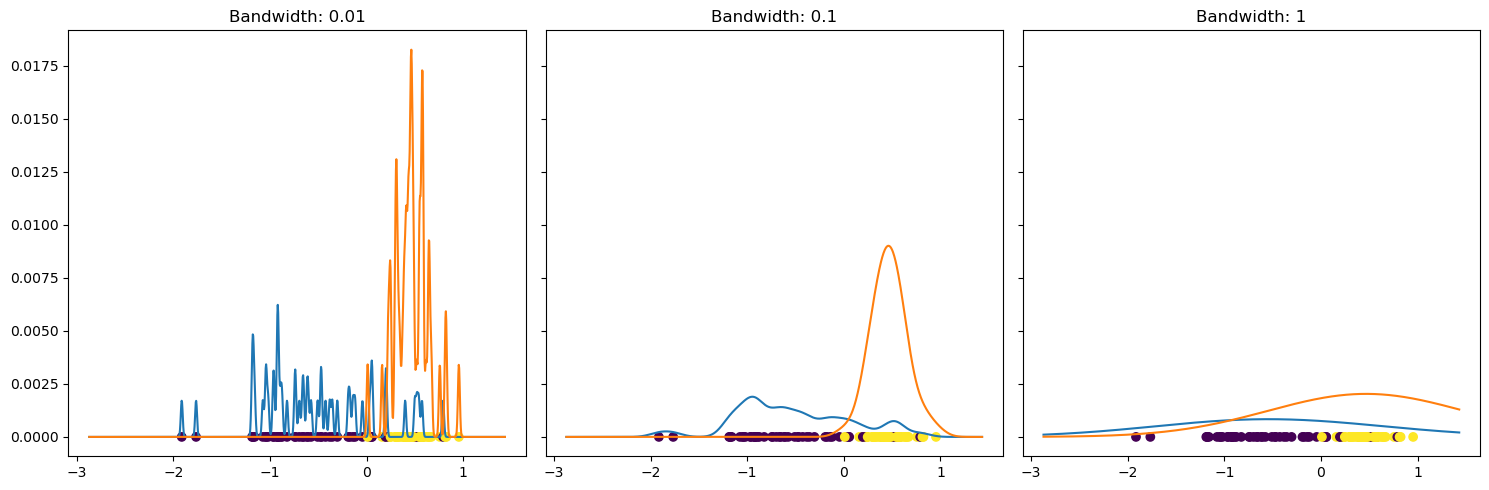

In [143]:
test_bws = [0.01, 0.1, 1]

x = np.linspace(np.min(X) * 1.5, np.max(X) * 1.5, 1000).reshape(-1, 1)

fig, axs = plt.subplots(1, len(test_bws), figsize=(15, 5), sharey=True)

for i, bw in enumerate(test_bws):
  bayeskde = BayesKDE(bandwidth=bw)
  bayeskde.fit(X, y)
  axs[i].scatter(X, np.zeros_like(y), c=y)
  p0 = np.exp(bayeskde.score_samples(x)[:, 0])
  p1 = np.exp(bayeskde.score_samples(x)[:, 1])
  p0 = p0 / np.sum(p0 + p1)
  p1 = p1 / np.sum(p0 + p1)
  axs[i].plot(x, p0)
  axs[i].plot(x, p1)
  axs[i].set_title(f'Bandwidth: {bw}')

plt.tight_layout()
plt.savefig('pdf_x_bw.png')
plt.show()

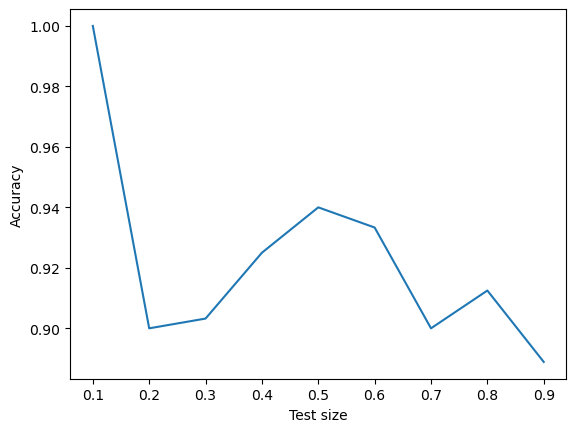

In [144]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

tsizes = np.linspace(0.1, 0.9, 9)

scores = []

for ts in tsizes:
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ts, random_state=0)
  bayeskde = BayesKDE(bandwidth=0.1)
  bayeskde.fit(X_train, y_train)
  y_pred = bayeskde.predict(X_test)
  scores.append(accuracy_score(y_test, y_pred))

plt.figure()
plt.plot(tsizes, scores)
plt.xlabel('Test size')
plt.ylabel('Accuracy')
plt.savefig('tsize_search.png')
plt.show()